# Fraud Detection — Exploratory Data Analysis

## Objective
The purpose of this project is to build a model that can detect fraudulent activity based on transaction data, and answer the following questions: 

- Q1. Why is `TRANSFER` riskier than `CASH_OUT`, despite being the only two fraud-bearing types?

- Q2. Is there a `TRANSFER` -> `CASH_OUT` behavioral chain — does fraud money move as `TRANSFER` then `CASH_OUT`?

In this notebook, the objective is to explore the structure and distributions in paysim.csv to (1) build an evidence-based hypothesis for why `TRANSFER` carries more fraud risk than `CASH_OUT`, and (2) confirm if there is a behavioral chain between `TRANSFER` and `CASH_OUT`. 

## Inputs
- `..\data\raw\paysim.csv`
- PaySim dataset — 6,362,620 transaction events, 11 columns
- Column Description:
    - `step`: Time is discretized: 1 step = 1 hour
    - `type`: `CASH_IN`, `CASH_OUT`, `DEBIT`, `PAYMENT`, `TRANSFER`
    - `amount`: Transaction amount (`float64`)
    - `nameOrig`: Name of origin Account (`str`)
    - `oldbalanceOrg`: Old account balance at origin (`float64`)
    - `newbalanceOrig`: New account balance at origin (`float64`)
    - `nameDest`: Name of destination account (`str`)
    - `oldbalanceDest`: Old account balance at destination (`float64`)
    - `newbalanceDest`: New account balance at destination (`float64`)
    - `isFraud`(Target): Fraudulent Transaction (`int64`)
    - `isFlaggedFraud`: Transaction flagged as fraudulent (`int64`)

## Outputs
- feature engineering steps
- chain-indicator hypothesis to test in feature engineering

## 1.1 Setup & Imports

Importing necessary libraries and setting plot styling and paths for reprodicability. 

In [2]:
import warnings
warnings.filterwarnings('ignore') # suppress outputs of warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme()
plt.style.use('seaborn-v0_8')
plt.rcParams['figure.figsize'] = (10, 6)

RAW_DATA_PATH = '../data/raw/paysim.csv'

## 1.2 Load Dataset

Using pandas to read the dataset and verifying the `.csv` has been loaded properly using `.shape` and `.head()`

In [16]:
df = pd.read_csv(RAW_DATA_PATH)
print(df.shape)
df.head()

(6362620, 11)


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


## 1.3 Sanity Checks

Checking for: incorrect data types, missing values, duplicates, any impossible or suspicious values, and unexpected categories. These checks ensure analysis is done without inaccurate or missing data, so that down stream models can be trained and tested on good data

In [4]:
df.dtypes

step                int64
type                  str
amount            float64
nameOrig              str
oldbalanceOrg     float64
newbalanceOrig    float64
nameDest              str
oldbalanceDest    float64
newbalanceDest    float64
isFraud             int64
isFlaggedFraud      int64
dtype: object

All data types look to be correct — continuous features like `amount` and `oldbalanceOrg` are `float64`, binary features are `int64`, and names are `str`. 

In [5]:
df.isnull().sum()

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

all sums are 0 therefore no obvious (`null`) missing values. 

Given the dataset was produced from simulated transaction there is a high potential for duplicated rows to exist, so `.duplicated().sum()` will give sums of any duplicate transaction.

In [7]:
df.duplicated().sum()

KeyboardInterrupt: 

np.int64(0) means there were no duplicate rows. 

I run `.describe()` to make sure continuous features are as they should be with no impossible values, and to get a peak at the overall distribution of the features. 

In [ ]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


`step`: large jump from 75% being 3.350000e+02 to max 7.430000e+02, so I expect to see a right-skewed distribution.

`amount`: 50% 7.487194e+04 and 75% 2.087215e+05 and max 9.244552e+07, so with this big jump I expect to see a right-skewed distribution.  

`oldbalanceOrg` and `newbalanceOrig`: Both have large differneces between their 75% and max (`oldbalanceOrg`: 75%=1.073152e+05, max=5.958504e+07 `newbalanceOrig`: 75%=1.442584e+05, max=4.958504e+07 ), so I expect to see a non-normal distribution. Additionally, the 25% 0.00 for `oldbalanceOrg` and 0.00 for 25% and 50% for `newbalanceOrig` is suspicious due to the high number of zeros in accounts. This could be a singal of potential data quality problem, or it could be a legitimate structural feature of this dataset — e.g. certain transactions types drains accounts, or many accounts have low/no-balance.

`oldbalanceDest` and `newbalanceDest`: Like `oldbalanceOrg` and `newbalanceOrig`, both `oldbalanceDest` and `newbalanceDest` have large differences between their 75% and max (`oldbalanceDest`: 75%=9.430367e+05 , max=3.560159e+08 `newbalanceDest`: 75%=1.111909e+06 , max=3.561793e+08), so I again expect to see a non-normal unbalanced distribution. Additioanlly, they also have 25% 0.00 which again could be a signal of a data quality problem or a legitimate structural feature. Lastly, there is a significant difference in the 75%, max, and mean of old and new balance origins and destinations.
|features | 75% | max | mean |
|---|---|---|---|
| oldbalanceOrg | 1.07e+05 | 5.96e+07 | 8.34e+05 |
| newbalanceOrig | 1.44e+05 | 4.96e+07 | 8.55e+05 |
| oldbalanceDest | 9.43e+05 | 3.56e+08 | 1.10e+06 |
| newbalanceDest | 1.11e+06 | 3.56e+08 | 1.22e+06 |

This could be a clue relevant to Q1 (why `Transfer` is riskier). This will be further investigated in bivariate analysis.  

`isFraud` and `isFlaggedFraud`: both these features have majority zeros in all % categories which signals that the target `isFraud` is imbalanced. 

I run `.describe(include='object')` to check if the three categorical features have any unexpected categories.

In [13]:
df.describe(include='object')

,type,nameOrig,nameDest
count,6362620,6362620,6362620
unique,5,6353307,2722362
top,CASH_OUT,C2098525306,C1286084959
freq,2237500,3,113


`type`: Everything appears to be as it should, 5 unique categoires, and `CASH_OUT` being the most common.

`nameOrig`: Majority are unique names with `C2098525306` being the most frequent account appearing 3 times — each account rarely originates more than one transaction. 

`nameDest`: Has far fewer unique names than `nameOrig` with `C1286084959` being the most frequent account appearing 113 times — some accounts receive many transactions. 

The difference in the origin and destination of accounts suggest that accounts in this dataset are primarily used for transfering money? This also makes my behavior chain question (Q2: `TRANSFER` -> `CASH_OUT`) more plausible to find in the actual data, because it shows that many of the accounts are transfering money to the destination accounts and then likely cashing out. 

## 1.4 Research Question Refinement

Initially, my research question was "does fraud differ by transaction type", and to ensure the dataset held the information needed to answer that question, not just train a model for fraud detection, I first ran `.value_counts()` on `isFraud` to see if there was enough fraudulent cases to train on. Then I used pandas function `.groupby()` and other aggregate functions to get the sum, mean, and count of the different transaction types to see the distribution of fraudulent cases among the transaction types.  

In [10]:
print(df['isFraud'].value_counts())
df['isFraud'].value_counts(normalize=True)

isFraud
0    6354407
1       8213
Name: count, dtype: int64


isFraud
0    0.998709
1    0.001291
Name: proportion, dtype: float64

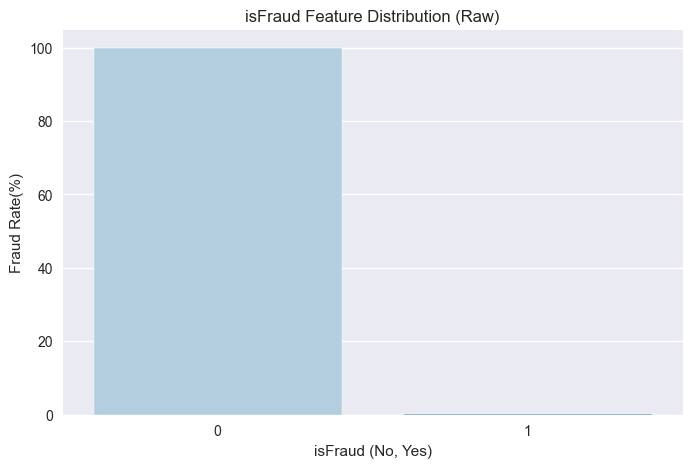

In [5]:
fraud_rates = df['isFraud'].value_counts(normalize=True) # the dataset is too large so this prevents running into memory error

plt.figure(figsize=(8, 5))
sns.barplot(x=fraud_rates.index, y=fraud_rates.values*100, palette='Blues')
plt.title('isFraud Feature Distribution (Raw)')
plt.xlabel('isFraud (No, Yes)')
plt.ylabel('Fraud Rate(%)')
plt.savefig('../images/target_distribution.png', bbox_inches='tight')
plt.show()

The plot visually shows the extreme imbalance between the two classes of the target variable — ~0.13% of transactions are fraudulent, a ~770:1 imbalance. This means that class weights will need to be adjusted, and evaluation will more dependent on recall than on accuracy alone. 


In [4]:
df.groupby('type')['isFraud'].agg(['sum', 'mean', 'count'])

,sum,mean,count
type,,,
CASH_IN,0,0.000000,1399284
CASH_OUT,4116,0.001840,2237500
DEBIT,0,0.000000,41432
PAYMENT,0,0.000000,2151495
TRANSFER,4097,0.007688,532909


Only two of the five `type` categories — `CASH_OUT` and `TRANSFER` — have cases of fraud. Additionally, although `CASH_OUT` has more cases of fraud (4116) than `TRANSFER` (4097), `TRANSFER` has a significantly higher rate of fraud (0.77%) than `CASH_OUT` (0.18%). This finding caused me to change my initial question of "does fraud differ by transaction types?" to: Q1 "Why is `TRANSFER` riskier than `CASH_OUT`, despite being the only two fraud-bearing types?" and Q2 "Is there a `TRANSFER` -> `CASH_OUT` behavioral chain — does fraud money move as `TRANSFER` then `CASH_OUT`?".


## 1.5 Univariate Analysis 

To visualize and analyze the features, looking at distributions and potential outliers, I conduct univariate analysis using a histogram with a KDE overlay for the continuous features (`step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`) and a bar plot of value counts for the categorical features (`type`, `isFlaggedFraud`).

Given the dataset's size (6.3M+ rows), plotting raw rows directly is not feasible (memmory error). For the continuous features, I apply a `log1p` transform (log(x+1), which safely handles the many true-zero values present in the balance columns) before plotting, and compute the histogram on the full dataset while sampling 100k rows for the KDE curve to keep runtime reasonable. 

For categorical features, `type` and `isFlaggedFraud` are plotted as bar plots of their value proportions (%), aggregated with `value_counts(normalize=True)` first to avoid the memory issues of plotting raw rows directly.

`nameOrig` and `nameDest` are excluded from this plot becuase both are high-cardinality identifier columns, and `nameOrig` in particular is near-unique per row, making a distribution plot meaningless. Instead, I inspect their most frequent values directly with `.value_counts().head(10)`, which reflects the asymmetry noted earlier (`nameOrig` rarely repeats, `nameDest` repeats heavily) and will be relevant to the chain analysis in Q2.

`isFraud` is not included here since its distribution was analyzed separately in the target distribution section above.

### Continuous Features
`step`, `amount`, `oldbalanceOrg`, `newbalanceOrig`, `oldbalanceDest`, `newbalanceDest`

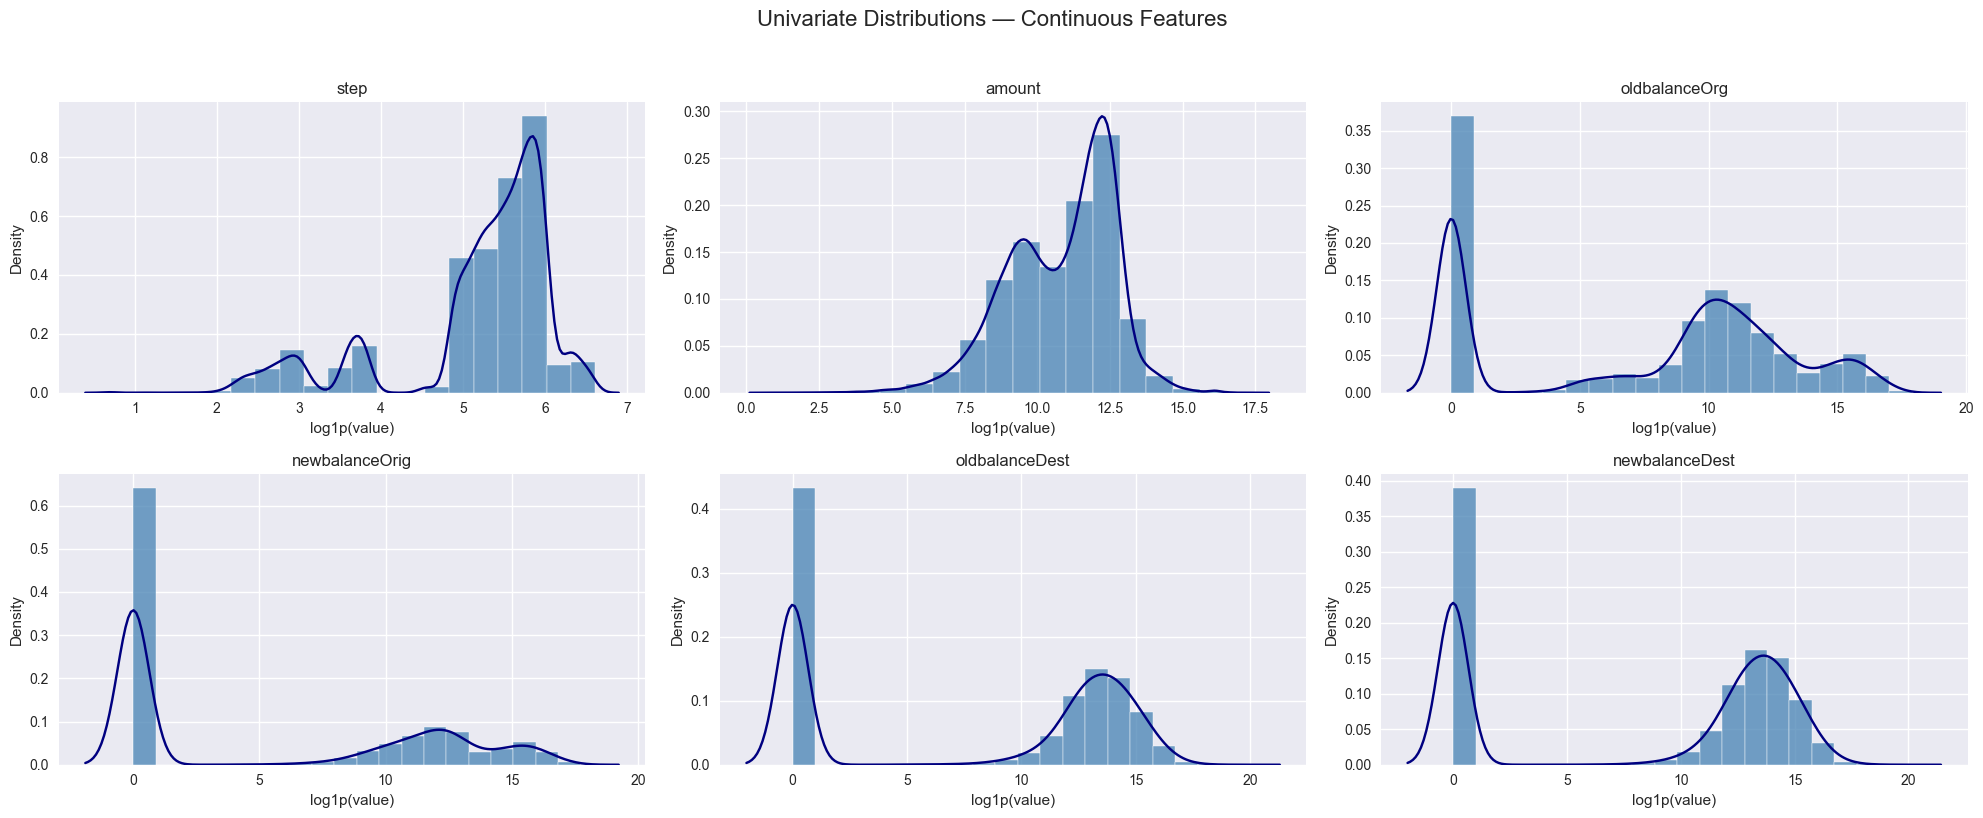

In [ ]:
continuous_features = ['step', 'amount', 'oldbalanceOrg', 'newbalanceOrig', 'oldbalanceDest', 'newbalanceDest']

fig, axes = plt.subplots(2, 3, figsize=(20, 8))
axes = axes.flatten()

for i, feature in enumerate(continuous_features):
    sns.histplot(np.log1p(df[feature]), bins=20, kde=False, ax=axes[i], color='steelblue', edgecolor='white', stat='density')
    sns.kdeplot(np.log1p(df[feature].sample(n=100_000, random_state=42)), ax=axes[i], color='navy') # so kde is done on sample of 100k for efficiency 
    axes[i].set_title(feature)
    axes[i].set_xlabel('log1p(value)')
    axes[i].set_ylabel('Density')

fig.suptitle('Univariate Distributions — Continuous Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/continuous_distributions.png', bbox_inches='tight')
plt.show()



The resulting distributions are zero-inflated: a large point-mass at zero (representing drained or newly created accounts) plus a right-skewed spread of nonzero balances — this is a log-scale artifact of the zero-inflation, not a true bimodal distribution in the original dollar scale.

### Categorical Features
`type`, `isFlaggedFraud`, `nameOrig`, `nameDest`

In [ ]:
if df['isFlaggedFraud'].dtype is int: # ensures I dont accidently rerun this code and then set all values to null. 
    df['isFlaggedFraud'] = df['isFlaggedFraud'].map({0: 'No', 1: 'Yes'})

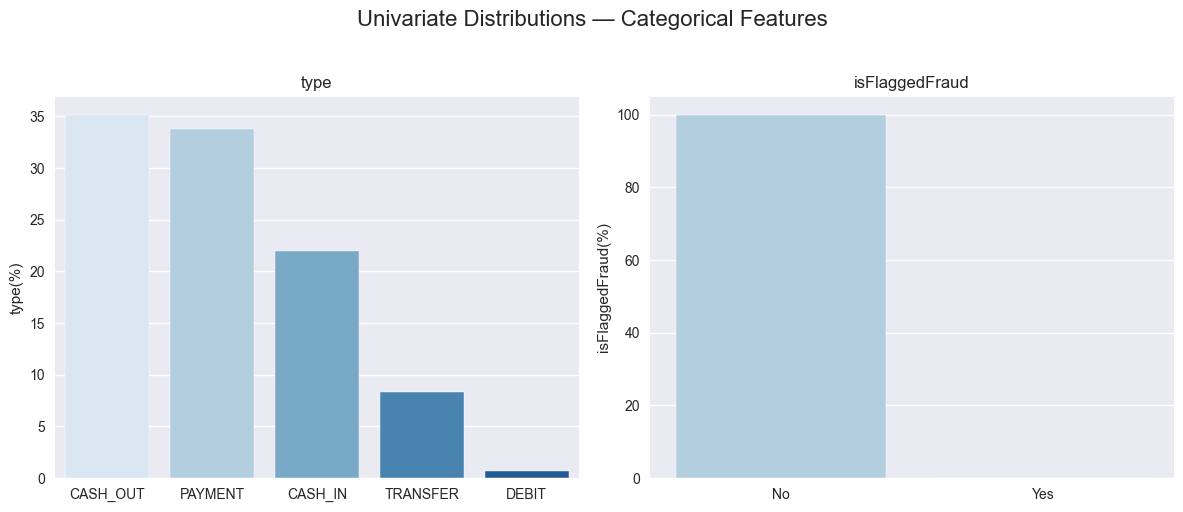

In [18]:
categorical_features = ['type', 'isFlaggedFraud']

fig, axes = plt.subplots(1, 2 , figsize=(12, 5))
axes = axes.flatten()

for i, feature in enumerate(categorical_features):
    feature_rates = df[feature].value_counts(normalize=True) 
    sns.barplot(x=feature_rates.index, y=feature_rates.values*100, ax=axes[i], palette='Blues')
    axes[i].set_title(feature)
    axes[i].set_xlabel('')
    axes[i].set_ylabel(f'{feature}(%)')

fig.suptitle('Univariate Distributions — Categorical Features', fontsize=16, y=1.02)
plt.tight_layout()
plt.savefig('../images/categorical_distributions.png', bbox_inches='tight')
plt.show()

In [ ]:
print(df['nameOrig'].value_counts().head(10))
df['nameDest'].value_counts().head(10)

nameOrig
C2098525306    3
C400299098     3
C1999539787    3
C1065307291    3
C545315117     3
C1976208114    3
C1784010646    3
C1530544995    3
C1902386530    3
C1677795071    3
Name: count, dtype: int64


nameDest
C1286084959    113
C985934102     109
C665576141     105
C2083562754    102
C248609774     101
C1590550415    101
C451111351      99
C1789550256     99
C1360767589     98
C1023714065     97
Name: count, dtype: int64

`nameOrig` max number of appearences is 3 while `nameDest` is 113. this imbalance suggest that many origin accounts are new and used only a few times while many destination accounts are used frequently which could be used for fraud. This connect my Q2 "Is there a `TRANSFER` -> `CASH_OUT` behavioral chain — does fraud money move as `TRANSFER` then `CASH_OUT`?" becuase it shows that many of these accounts are cashing out maybe or something? 

## 1.6 Bivariate Analysis

### Continuous Features

### Categorical Features